In [2]:
import matplotlib.pyplot as plt
import jax
import numpy as np
import json
import glob
import os
from matplotlib.colors import LinearSegmentedColormap
import re

def extract_number_from_model_code(model_code):
    """
    Extract the number at the end of the model code.

    Args:
        model_code (str): The model code string.

    Returns:
        int or None: The extracted number, or None if no number is found.
    """
    match = re.search(r'\d+$', model_code)
    return int(match.group()) if match else None






In [3]:
def aggregate_results(result_dir, dataset, model_code):
    """Aggregate and average results across different seeds, returning 2D arrays for test accuracy and standard deviation."""
    result_files = glob.glob(os.path.join(result_dir, f"results_{dataset}_*.json"))
    
    if not result_files:
        print(f"No results file by name results_{dataset}_*.json found.")
        return None, None, None
    print(f"Results in results_{dataset}_*.json opened.")
    # Organize results by (n_layers, hidden_dim, decay)
    aggregated = {}
    for file in result_files:
        with open(file, "r") as f:
            data = json.load(f)
            for key_str, results in data.items():
                key = eval(key_str)  # Convert string back to tuple (n_layers, hidden_dim, decay)
                # print(key[0])
                if key not in aggregated:
                    aggregated[key] = {"test_acc": [], "test_loss": [], "n_params": [], "n_layers": [], "steepness": []}
                aggregated[key]["test_acc"].extend([result["test_acc"] for result in results])
                aggregated[key]["test_loss"].extend([result["test_loss"] for result in results])
                aggregated[key]["n_params"].append(results[0]["n_params"])  # Assuming n_params is constant
                aggregated[key]["n_layers"].append(results[0]["n_layers"])  # Assuming n_layers is constant
                aggregated[key]["steepness"].append(result["steepness"] for result in results)  # Assuming steepness is constant
    aggregated_by_layer= {}
    aggregated_by_params = {}

    if dataset == "cifar10":
        param_nums = np.array([500000,750000, 1000000, 1500000, 2000000])
    else:
        param_nums = np.array([1700, 3500, 5000, 10000, 20000])
    
    for key, results in aggregated.items():
        param_num = results["n_params"][0]
        key_param = param_nums[np.abs(param_nums - param_num).argmin()]

        mean_acc = np.mean(results["test_acc"])
        std_acc = np.std(results["test_acc"])
        mean_loss = np.mean(results["test_loss"])
        std_loss = np.std(results["test_loss"])
        mean_params = np.mean(results["n_params"])
        mean_layers = np.mean(results["n_layers"])
        steepness = extract_number_from_model_code(model_code)
        
        if key[-1] == model_code:
            if key[0] not in aggregated_by_layer:
                aggregated_by_layer[key[0]] = {"test_acc": [], "test_acc_std": [], "test_loss": [], "test_loss_std": [], "n_params": [], "n_layers": [], "steepness": []}
            aggregated_by_layer[key[0]]["test_acc"].extend([mean_acc])
            aggregated_by_layer[key[0]]["test_acc_std"].extend([std_acc])
            aggregated_by_layer[key[0]]["test_loss"].extend([mean_loss])
            aggregated_by_layer[key[0]]["test_loss_std"].extend([std_loss])
            aggregated_by_layer[key[0]]["n_params"].append(mean_params)  # Assuming n_params is constant
            aggregated_by_layer[key[0]]["n_layers"].append(mean_layers)  # Assuming n_layers is constant
            aggregated_by_layer[key[0]]["steepness"].append(steepness)
            
            if key_param not in aggregated_by_params:
                aggregated_by_params[key_param] = {"test_acc": [], "test_acc_std": [], "test_loss": [], "test_loss_std": [], "n_params": [], "n_layers": [], "steepness": []}
            aggregated_by_params[key_param]["test_acc"].extend([mean_acc])
            aggregated_by_params[key_param]["test_acc_std"].extend([std_acc])
            aggregated_by_params[key_param]["test_loss"].extend([mean_loss])
            aggregated_by_params[key_param]["test_loss_std"].extend([std_loss])
            aggregated_by_params[key_param]["n_params"].append(mean_params)
            aggregated_by_params[key_param]["n_layers"].append(mean_layers)
            aggregated_by_params[key_param]["steepness"].append(steepness)


    return aggregated, aggregated_by_layer, aggregated_by_params

    # return acc_decay_true, acc_std_decay_true, acc_decay_false, acc_std_decay_false, loss_decay_true, loss_std_decay_true, loss_decay_false, loss_std_decay_false, unique_dims, unique_layers

In [25]:
# # PLOT CIFAR10 DATA

# # acc_decay_true, acc_std_decay_true, acc_decay_false, acc_std_decay_false, loss_decay_true, loss_std_decay_true, loss_decay_false, loss_std_decay_false, unique_dims, unique_layers = aggregate_results("/home/christian/LearningJAX/Flax/results", "cifar10")
# aggregated, aggregated_by_layer_decay, aggregated_by_params_decay, aggregated_by_layer_nodecay, aggregated_by_params_nodecay = aggregate_results("/home/christian/LearningJAX/Flax/results", "cifar10")

In [4]:
# # plot accuracy over parameters for different layer sizes for CIFAR10
# to_plot = "test_acc"; y_label = "Test Accuracy"
# fig, axes = plt.subplots(2, 4, figsize=(15, 8))
# axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# unique_layers = sorted(aggregated_by_layer_decay.keys())
# max_std = max([max(aggregated_by_layer_decay[key]["test_acc_std"]) for key in unique_layers])
# results_decay = aggregated_by_layer_decay.get(unique_layers[-1])
# results_nodecay = aggregated_by_layer_nodecay.get(unique_layers[-1])
# y_min = 0.2
# y_max = 0.6
# x_min = 0
# x_max = sorted(aggregated_by_params_decay.keys())[-1]+(sorted(aggregated_by_params_decay.keys())[0])

# for i, key in enumerate(unique_layers):
#     ax = axes[i]
#     results_decay = aggregated_by_layer_decay.get(key)
#     results_nodecay = aggregated_by_layer_nodecay.get(key)
#     ax.errorbar(results_nodecay["n_params"], results_nodecay[to_plot], yerr=results_nodecay[to_plot+"_std"], label=f"no decay", color="darkgreen", marker="o", markerfacecolor="white")
#     ax.errorbar(results_decay["n_params"], results_decay[to_plot], yerr=results_decay[to_plot+"_std"], label=f"decay", color="teal", marker="o")
#     ax.set_ylim(y_min, y_max)
#     ax.set_xlim(x_min, x_max)
#     ax.set_xlabel("Number of Parameters", fontsize=8)
#     ax.set_ylabel("Test Accuracy", fontsize=8)
#     ax.set_title(f"{key} layers", fontsize=10)
#     if i == 0:
#         ax.legend(loc="upper right", fontsize=8)

# axes[-1].axis("off")
# plt.tight_layout()
# plt.show()


In [5]:
# # plot accuracy over layers for different parameter counts for CIFAR10
# to_plot = "test_acc"; y_label = "Test Accuracy"
# fig, axes = plt.subplots(2, 3, figsize=(11.25, 8))
# axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# unique_params = sorted(aggregated_by_params_decay.keys())
# max_std = max([max(aggregated_by_params_decay[key]["test_acc_std"]) for key in unique_params])
# y_min = 0.2
# y_max = 0.6
# x_min = 1
# x_max = sorted(aggregated_by_layer_decay.keys())[-1]+(sorted(aggregated_by_layer_decay.keys())[0]-1)

# for i, key in enumerate(unique_params):
#     ax = axes[i]
#     results_decay = aggregated_by_params_decay.get(key)
#     results_nodecay = aggregated_by_params_nodecay.get(key)
#     ax.errorbar(results_nodecay["n_layers"], results_nodecay[to_plot], yerr=results_nodecay[to_plot+"_std"], label=f"no decay", color="darkgreen", marker="o", markerfacecolor="white")
#     ax.errorbar(results_decay["n_layers"], results_decay[to_plot], yerr=results_decay[to_plot+"_std"], label=f"decay", color="teal", marker="o")
#     ax.set_ylim(y_min, y_max)
#     ax.set_xlim(x_min, x_max)
#     ax.set_xlabel("Number of Layers", fontsize=8)
#     ax.set_ylabel("Test Accuracy", fontsize=8)
#     ax.set_title(f"{key*1e-3}k Parameters", fontsize=10)
#     if i == 0:
#         ax.legend(loc="upper right", fontsize=8)

# axes[-1].axis("off")
# plt.tight_layout()
# plt.show()

In [14]:
# aggregated, aggregated_by_layer_decay, aggregated_by_params_decay  = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", True)
# _, aggregated_by_layer_nodecay, aggregated_by_params_nodecay = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", False)

# aggregated_fl, aggregated_by_layer_fl, aggregated_by_params_fl = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnistfirstlayer", False)


# with steepness 10,000
aggregated, aggregated_by_layer_decay, aggregated_by_params_decay = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", 'alllayer')
_, aggregated_by_layer_nodecay, aggregated_by_params_nodecay = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", 'nolayer')

aggregated_fl, aggregated_by_layer_fl, aggregated_by_params_fl = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnistfirstlayer", 'firstlayer')


Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnistfirstlayer_*.json opened.


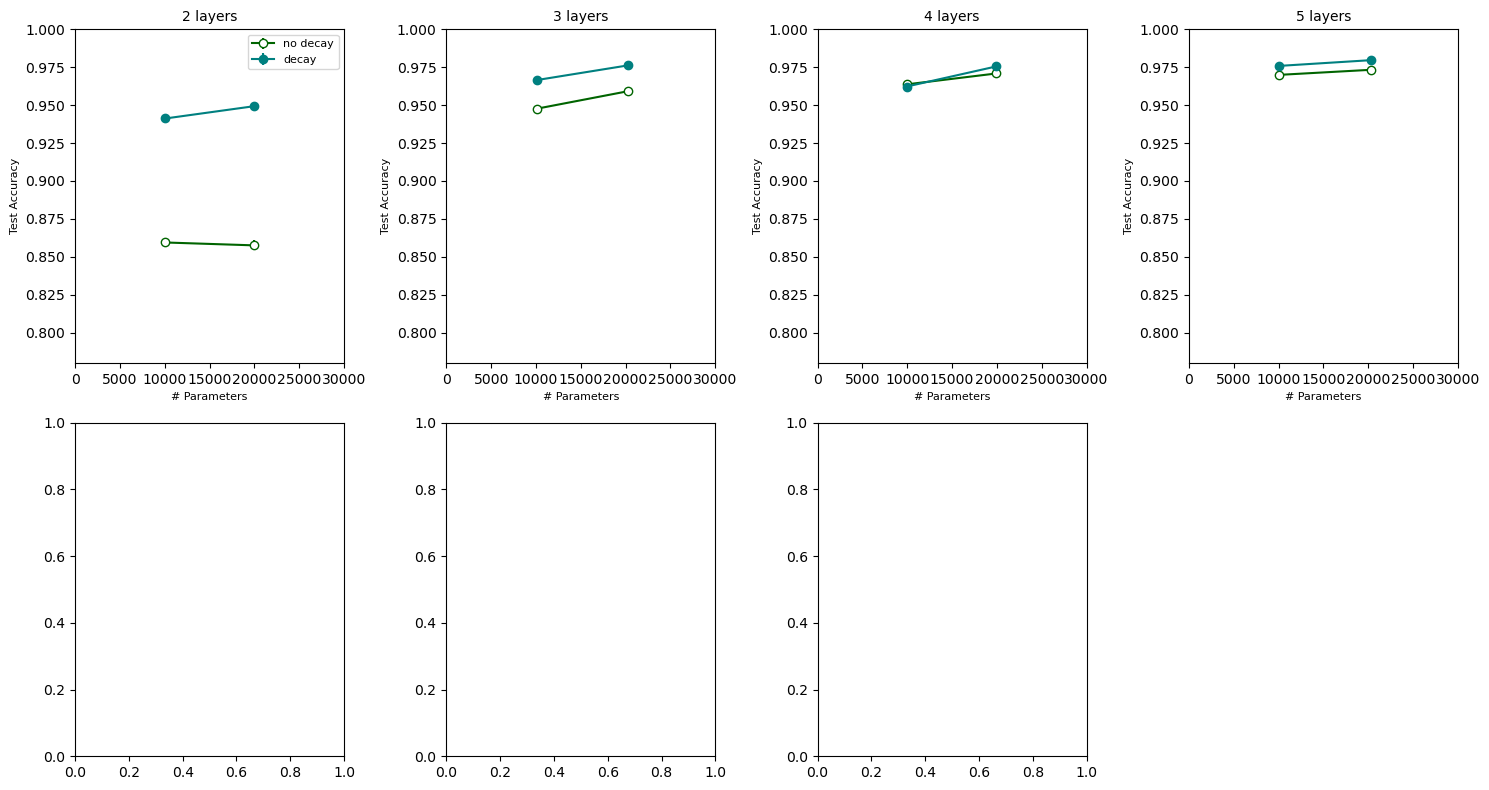

In [10]:
# plot accuracy over parameters for different layer sizes for MNIST
to_plot = "test_acc"; y_label = "Test Accuracy"
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

unique_layers = sorted(aggregated_by_layer_decay.keys())
max_std = max([max(aggregated_by_layer_decay[key]["test_acc_std"]) for key in unique_layers])
results_decay = aggregated_by_layer_decay.get(unique_layers[-1])
results_nodecay = aggregated_by_layer_nodecay.get(unique_layers[-1])
y_min = 0.78
y_max = 1
x_min = 0
x_max = sorted(aggregated_by_params_decay.keys())[-1]+(sorted(aggregated_by_params_decay.keys())[0])

for i, key in enumerate(unique_layers):
    ax = axes[i]
    results_decay = aggregated_by_layer_decay.get(key)
    results_nodecay = aggregated_by_layer_nodecay.get(key)
    results_firstlayer = aggregated_by_layer_fl.get(key)
    if results_firstlayer is not None:
        ax.errorbar(results_firstlayer["n_params"], results_firstlayer[to_plot], yerr=results_firstlayer[to_plot+"_std"], label=f"first layer decay", color="darkblue", marker="^")
    ax.errorbar(results_nodecay["n_params"], results_nodecay[to_plot], yerr=results_nodecay[to_plot+"_std"], label=f"no decay", color="darkgreen", marker="o", markerfacecolor="white")
    ax.errorbar(results_decay["n_params"], results_decay[to_plot], yerr=results_decay[to_plot+"_std"], label=f"decay", color="teal", marker="o")
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("# Parameters", fontsize=8)
    ax.set_ylabel("Test Accuracy", fontsize=8)
    ax.set_title(f"{key} layers", fontsize=10)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

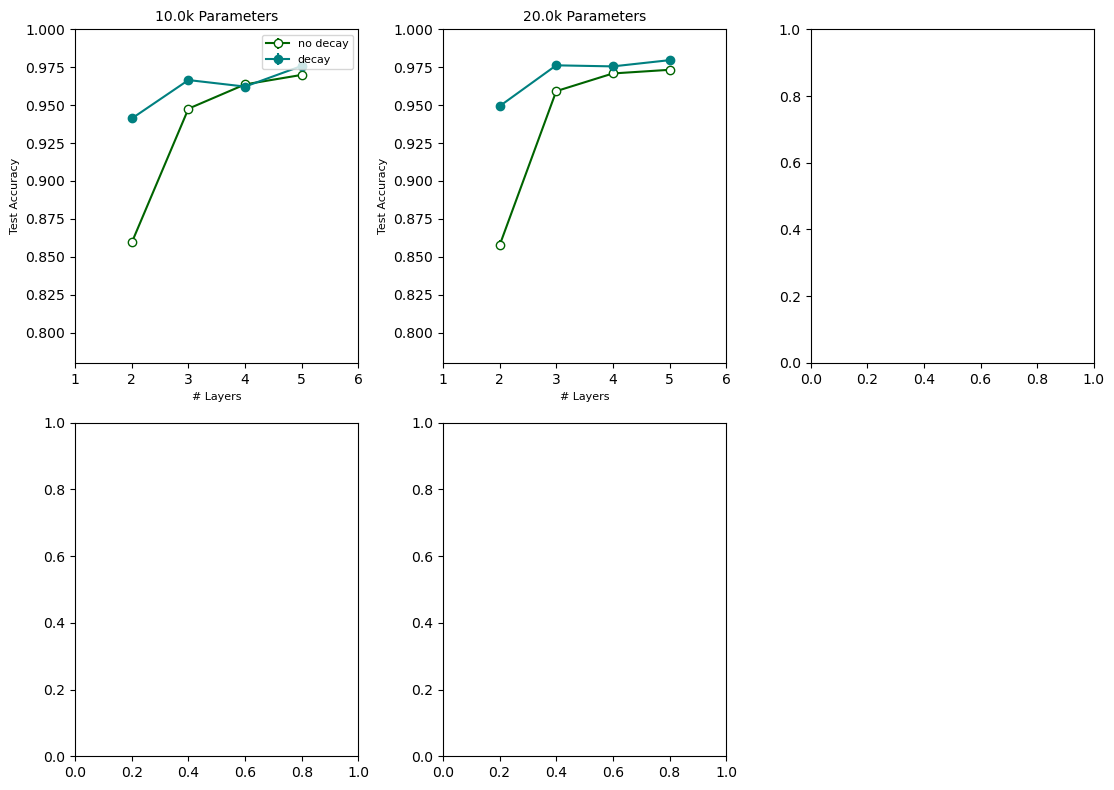

In [12]:
# plot accuracy/loss over layers for different parameter counts for MNIST
to_plot = "test_acc"; y_label = "Test Accuracy"
fig, axes = plt.subplots(2, 3, figsize=(11.25, 8))
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

unique_params = sorted(aggregated_by_params_decay.keys())
max_std = max([max(aggregated_by_params_decay[key]["test_acc_std"]) for key in unique_params])
y_min = 0.78
y_max = 1
x_min = 1
x_max = sorted(aggregated_by_layer_decay.keys())[-1]+(sorted(aggregated_by_layer_decay.keys())[0]-1)

for i, key in enumerate(unique_params):
    ax = axes[i]
    results_decay = aggregated_by_params_decay.get(key)
    results_nodecay = aggregated_by_params_nodecay.get(key)
    results_firstlayer = aggregated_by_params_fl.get(key)
    if results_firstlayer is not None:
        ax.errorbar(results_firstlayer["n_layers"], results_firstlayer[to_plot], yerr=results_firstlayer[to_plot + "_std"], label=f"first layer decay", color="darkblue", marker="^")
    ax.errorbar(results_nodecay["n_layers"], results_nodecay[to_plot], yerr=results_nodecay[to_plot + "_std"], label=f"no decay", color="darkgreen", marker="o", markerfacecolor="white")
    ax.errorbar(results_decay["n_layers"], results_decay[to_plot], yerr=results_decay[to_plot + "_std"], label=f"decay", color="teal", marker="o")
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("# Layers", fontsize=8)
    ax.set_ylabel(y_label, fontsize=8)
    ax.set_title(f"{key*1e-3}k Parameters", fontsize=10)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [5]:
aggregated, aggregated_by_layer_all, aggregated_by_params_all = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", 'alllayer')
_, aggregated_by_layer_nodecay, aggregated_by_params_nodecay = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", 'nolayer')

aggregated_fl, aggregated_by_layer_fl, aggregated_by_params_fl = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnistfirstlayer", 'firstlayer')



Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnistfirstlayer_*.json opened.


In [4]:
aggregated_by_layer_all = []
aggregated_by_params_all = []
aggregated_by_layer_no = []
aggregated_by_params_no = []
aggregated_by_layer_fl = []
aggregated_by_params_fl = []

for stp in [10, 20, 100, 1000, 10000, "hard"]:
    model_code = "alllayer_dyn_stpns_" + str(stp)
    _, aggregated_by_layer, aggregated_by_params = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", model_code)
    aggregated_by_layer_all.append(aggregated_by_layer)
    aggregated_by_params_all.append(aggregated_by_params)
    model_code = "nolayer_dyn_stpns_" + str(stp)
    _, aggregated_by_layer, aggregated_by_params = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", model_code)
    aggregated_by_layer_no.append(aggregated_by_layer)
    aggregated_by_params_no.append(aggregated_by_params)
    model_code = "firstlayer_dyn_stpns_" + str(stp)
    _, aggregated_by_layer, aggregated_by_params = aggregate_results("/home/christian/LearningJAX/Flax/results", "mnist", model_code)
    aggregated_by_layer_fl.append(aggregated_by_layer)
    aggregated_by_params_fl.append(aggregated_by_params)

print(aggregated_by_layer_fl)



Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
Results in results_mnist_*.json opened.
[{2: {'test_acc': [0.9498197138309479, 0.9541265964508057], 'test_acc_std': [0.002103358507156372, 0.0], 'test_loss': [0.16413946449756622, 0.14587998390197754], 'test_loss_std': [0.005214035511016846, 0.0], 'n_params': [10060.0, 19978.0], 'n_layers': [2.0, 2.0], 'steepness': [10

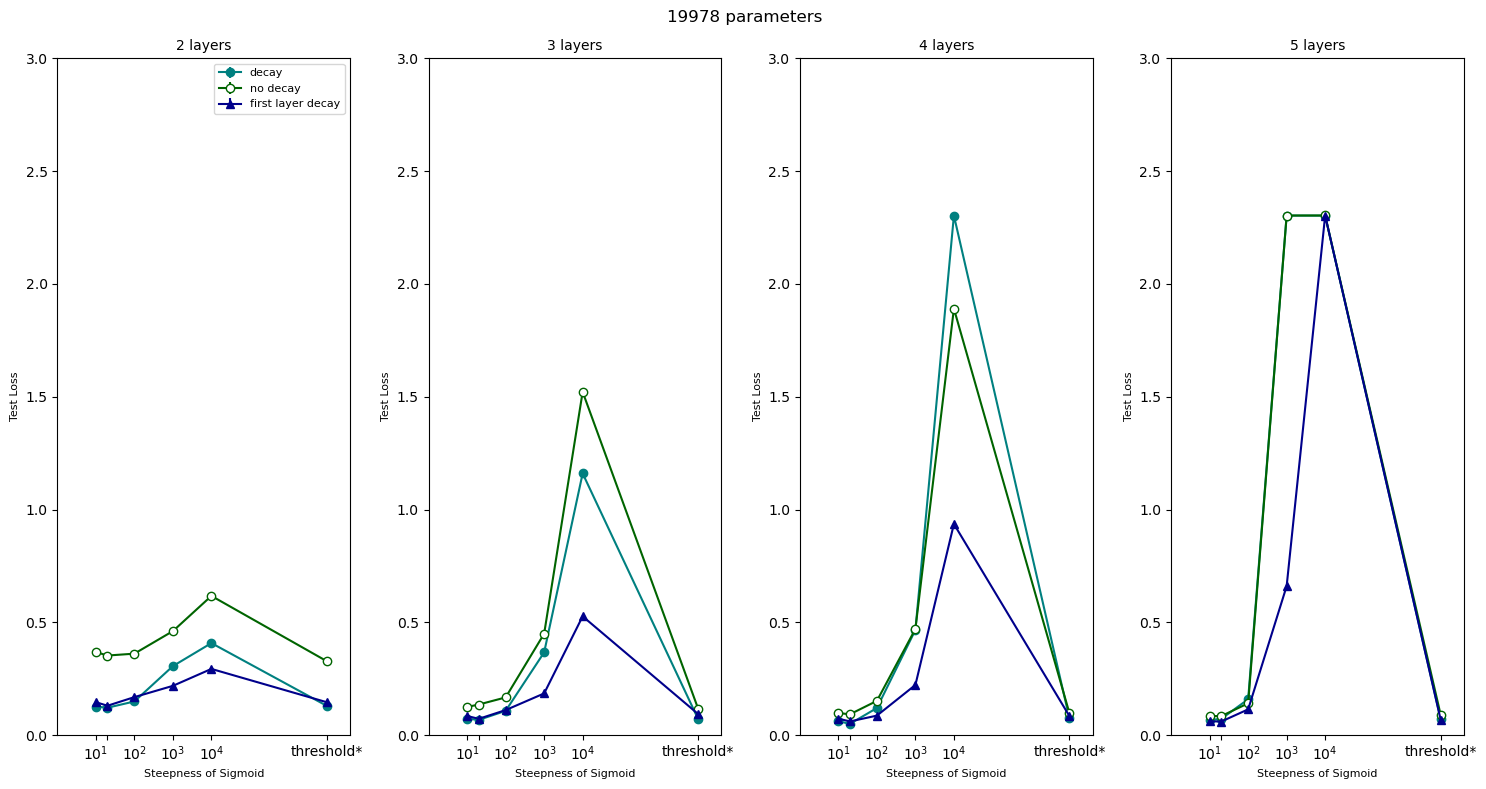

In [24]:
import matplotlib.ticker as ticker

steepness_sweep = [10, 20, 100, 1000, 10000, "hard"]

parameter_index = 1 # depending on how many parameters I want to plot

# plot accuracy over parameters for different layer sizes for MNIST
to_plot = "test_loss"; y_label = "Test Loss"
fig, axes = plt.subplots(1, 4, figsize=(15, 8))
fig.suptitle(f"{int(aggregated_by_layer_all[0][2]["n_params"][parameter_index])} parameters", fontsize=12)
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

unique_layers = sorted(aggregated_by_layer_all[0].keys())
max_std = max([max(aggregated_by_layer_all[0][key]["test_loss_std"]) for key in unique_layers])
results_decay = aggregated_by_layer_no[0].get(unique_layers[-1])
results_nodecay = aggregated_by_layer_no[0].get(unique_layers[-1])
if to_plot == "test_acc":
    y_min = 0.05
    y_max = 1
else:
    y_min = 0.0
    y_max = 3
x_min = 1
x_max = 10000000*4

for i, key in enumerate(unique_layers):
    ax = axes[i]
    x = steepness_sweep
    x[-1] = 10000000
    y_all = []
    y_no = []
    y_fl = []
    y_all_std = []
    y_no_std = []
    y_fl_std = []

    for k, stp in enumerate(steepness_sweep):
        results_decay = aggregated_by_layer_all[k].get(key)
        results_nodecay = aggregated_by_layer_no[k].get(key)
        results_firstlayer = aggregated_by_layer_fl[k].get(key)

        y_all.append(results_decay[to_plot][parameter_index]); y_all_std.append(results_decay[to_plot + "_std"][parameter_index])
        y_no.append(results_nodecay[to_plot][parameter_index]); y_no_std.append(results_nodecay[to_plot + "_std"][parameter_index])
        y_fl.append(results_firstlayer[to_plot][parameter_index]); y_fl_std.append(results_firstlayer[to_plot + "_std"][parameter_index])

    # if results_firstlayer is not None:
    #     ax.errorbar(x, results_firstlayer[to_plot], yerr=results_firstlayer[to_plot+"_std"], label=f"first layer decay", color="darkblue", marker="^")
    # ax.errorbar(results_nodecay["n_params"], results_nodecay[to_plot], yerr=results_nodecay[to_plot+"_std"], label=f"no decay", color="darkgreen", marker="o", markerfacecolor="white")
    # ax.errorbar(results_decay["n_params"], results_decay[to_plot], yerr=results_decay[to_plot+"_std"], label=f"decay", color="teal", marker="o")
    ax.errorbar(x, y_all, yerr=y_all_std, label=f"decay", color="teal", marker="o")
    ax.errorbar(x, y_no, yerr=y_no_std, label=f"no decay", color="darkgreen", marker="o", markerfacecolor="white")
    ax.errorbar(x, y_fl, yerr=y_fl_std, label=f"first layer decay", color="darkblue", marker="^")
    ax.set_xscale('log')
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(x)

    xticks = ax.get_xticks()  # Get current x-tick positions
    xticklabels = ax.get_xticklabels()  # Get current x-tick labels

    xticklabels = [label.get_text() for label in xticklabels]  # Extract text from labels
    xticklabels[-1] = "threshold*"  # Replace the last label

    # Set the modified labels back
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

    ax.set_xlabel("Steepness of Sigmoid", fontsize=8)
    ax.set_ylabel(y_label, fontsize=8)
    ax.set_title(f"{key} layers", fontsize=10)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

# axes[-1].axis("off")
plt.tight_layout()
plt.show()